In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [7]:
with open("../data/02-result/drugs_df.pkl","rb") as f:
    drugs_df =pickle.load(f)
with open("../data/02-result/diseases_df.pkl","rb") as f:
    diseases_df =pickle.load(f)
with open("../data/02-result/trials_df.pkl","rb") as f:
    trials_df =pickle.load(f)
with open("../data/02-result/indications_df.pkl","rb") as f:
    indications_df =pickle.load(f)
with open("../data/01-result/embeddings_df.pkl","rb") as f:
    embeddings_df =pickle.load(f)
with open("../data/01-result/fingerprints_df.pkl","rb") as f:
    fingerprints_df =pickle.load(f)

# TODO: Visualization + missing value imputation + outlier detection

# Missing values

In [8]:
df = drugs_df.drop(columns=drugs_df.filter(regex=r"^(drug_path_|FP_)").columns)
# Simple summary
print(df.isna().sum().sort_values(ascending=False))

# Visual overview
plt.figure(figsize=(10, 6))
msno.matrix(df, sparkline=False)
plt.title("Missing Values Overview", fontsize=14)
plt.show()

# Alternatively, a heatmap to see missing patterns
msno.heatmap(df, cmap="coolwarm")
plt.title("Missingness Heatmap On Drug Features")
plt.show()

In [9]:
scaler = StandardScaler(with_mean=True, with_std=True)
pca = PCA(n_components=10)

drugs_scaled =scaler.fit_transform(drugs_df.select_dtypes(include="number"))

pc =  pca.fit_transform(drugs_scaled)

,label,biotherapeutic,chemical_probe,dosed_ingredient,inorganic_flag,natural_product,oral,orphan,parenteral,prodrug,...,disease_path_41,disease_path_42,disease_path_43,disease_path_44,disease_path_45,disease_path_46,disease_path_47,disease_path_48,disease_path_49,name_similarity
0,True,0,0,True,0,1,True,0,True,0,...,0.005239,0.029122,-0.016002,0.079853,0.020295,-0.010043,0.036285,0.005089,0.042312,0.075028
1,False,0,0,True,0,1,True,0,False,0,...,-0.020228,-0.007647,-0.078747,-0.050006,0.065512,-0.011153,0.089468,0.046286,0.097443,0.094691
4,True,0,0,True,0,1,True,1,False,0,...,0.048651,-0.002516,0.138820,-0.022043,-0.046279,0.046063,0.005258,0.015994,0.076821,0.249712
7,True,0,0,True,0,0,True,0,False,0,...,0.034670,-0.013284,0.045651,0.080481,-0.062777,0.025146,-0.013067,0.021488,-0.002977,0.125380
8,True,0,0,True,0,0,True,0,False,0,...,0.018464,-0.057149,0.012485,-0.016685,0.028022,0.021635,-0.030254,-0.056211,-0.044441,0.221504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4908,False,0,0,False,0,0,False,0,False,0,...,-0.010436,0.096810,0.012056,0.026490,-0.000892,-0.010267,0.051443,0.006115,-0.004349,0.035953
4909,False,0,0,False,0,1,False,0,False,0,...,0.046149,-0.045122,0.067429,0.066541,0.070020,0.001434,-0.017607,0.003372,-0.011841,0.138401
4910,False,0,0,False,0,0,False,0,False,0,...,-0.015753,0.026205,0.024638,0.050006,0.034497,0.001371,0.022380,0.002135,0.033640,0.173468
4911,False,0,0,False,0,0,False,0,False,0,...,0.091123,-0.056180,0.142815,0.129173,-0.101705,0.039424,-0.059613,0.069855,0.043001,0.093383


# Merge and curate all data

### TODO: missing value imputation + outlier detection as well for merged data?

In [21]:
drugs_df = drugs_df.merge(fingerprints_df, on="drug_id")
diseases_df["disease_id"] = diseases_df["disease_id"].str.replace("_",":")
embeddings_df["disease_id"] = embeddings_df["disease_id"].str.replace("_",":")
merged_df = indications_df.merge(drugs_df, on="drug_id").merge(diseases_df, on="disease_id").merge(embeddings_df, on =["disease_id", "drug_id"])

In [19]:
merged_df = merged_df.select_dtypes(exclude=["object"])
merged_df = merged_df.drop(columns=["first_approval", "withdrawn_flag", "usan_year", "black_box_warning", "first_in_class"])
merged_df = merged_df[ ~merged_df["biotherapeutic"].astype(bool) ]
merged_df = merged_df.rename(columns={"overall_success" : "label"})
merged_df = merged_df[merged_df.label.notna() ]
merged_df

SyntaxError: invalid syntax (2228846188.py, line 3)

In [25]:
merged_df = merged_df.select_dtypes(exclude=["object"])
# merged_df = merged_df.drop(columns=["first_approval", "withdrawn_flag", "usan_year", "black_box_warning", "first_in_class"])
merged_df = merged_df[ ~merged_df["biotherapeutic"].astype(bool) ]
merged_df = merged_df.rename(columns={"overall_success" : "label"})
merged_df = merged_df[merged_df.label.notna() ]
merged_df

,label,biotherapeutic,chemical_probe,dosed_ingredient,inorganic_flag,natural_product,oral,orphan,parenteral,prodrug,...,disease_path_41,disease_path_42,disease_path_43,disease_path_44,disease_path_45,disease_path_46,disease_path_47,disease_path_48,disease_path_49,name_similarity
0,True,0,0,True,0,1,True,0,True,0,...,0.005239,0.029122,-0.016002,0.079853,0.020295,-0.010043,0.036285,0.005089,0.042312,0.075028
1,False,0,0,True,0,1,True,0,False,0,...,-0.020228,-0.007647,-0.078747,-0.050006,0.065512,-0.011153,0.089468,0.046286,0.097443,0.094691
4,True,0,0,True,0,1,True,1,False,0,...,0.048651,-0.002516,0.138820,-0.022043,-0.046279,0.046063,0.005258,0.015994,0.076821,0.249712
7,True,0,0,True,0,0,True,0,False,0,...,0.034670,-0.013284,0.045651,0.080481,-0.062777,0.025146,-0.013067,0.021488,-0.002977,0.125380
8,True,0,0,True,0,0,True,0,False,0,...,0.018464,-0.057149,0.012485,-0.016685,0.028022,0.021635,-0.030254,-0.056211,-0.044441,0.221504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4908,False,0,0,False,0,0,False,0,False,0,...,-0.010436,0.096810,0.012056,0.026490,-0.000892,-0.010267,0.051443,0.006115,-0.004349,0.035953
4909,False,0,0,False,0,1,False,0,False,0,...,0.046149,-0.045122,0.067429,0.066541,0.070020,0.001434,-0.017607,0.003372,-0.011841,0.138401
4910,False,0,0,False,0,0,False,0,False,0,...,-0.015753,0.026205,0.024638,0.050006,0.034497,0.001371,0.022380,0.002135,0.033640,0.173468
4911,False,0,0,False,0,0,False,0,False,0,...,0.091123,-0.056180,0.142815,0.129173,-0.101705,0.039424,-0.059613,0.069855,0.043001,0.093383


In [ ]:
merged_df.label.value_counts()

label
False    1290
True      699
Name: count, dtype: Int64

In [26]:
merged_df.label.value_counts()

label
False    1290
True      699
Name: count, dtype: Int64

In [27]:
with open("../data/03-result/drugs_df.pkl","wb") as f:
    pickle.dump(drugs_df,f)
with open("../data/03-result/diseases_df.pkl","wb") as f:
    pickle.dump(diseases_df,f)
with open("../data/03-result/trials_df.pkl","wb") as f:
    pickle.dump(trials_df,f)
with open("../data/03-result/indications_df.pkl","wb") as f:
    pickle.dump(indications_df,f)
with open("../data/03-result/merged_df.pkl","wb") as f:
    pickle.dump(merged_df,f)

NameError: name 'final_drugs_df' is not defined

In [28]:
with open("../data/03-result/drugs_df.pkl","wb") as f:
    pickle.dump(drugs_df,f)
with open("../data/03-result/diseases_df.pkl","wb") as f:
    pickle.dump(diseases_df,f)
with open("../data/03-result/trials_df.pkl","wb") as f:
    pickle.dump(trials_df,f)
with open("../data/03-result/indications_df.pkl","wb") as f:
    pickle.dump(indications_df,f)
with open("../data/03-result/merged_df.pkl","wb") as f:
    pickle.dump(merged_df,f)

### SANDBOX

# Adapt notes go here.

In [29]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
test= drugs_df.select_dtypes(include=numerics)
test = test.loc[:,test.apply(lambda col : len(pd.unique(col))>3)]
sns.pairplot(test, kind="scatter")

NameError: name 'numeric_cols' is not defined

In [ ]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
test= drugs_df.select_dtypes(include=numerics)
test = test.loc[:,test.apply(lambda col : len(pd.unique(col))>3)]
sns.pairplot(test, kind="scatter")

KeyboardInterrupt: 

helm_notation           647
first_approval          335
psa                     293
aromatic_rings          293
hba                     293
hbd                     293
heavy_atoms             293
np_likeness_score       293
num_ro5_violations      293
alogp                   293
qed_weighted            293
ro3_pass                293
rtb                     293
usan_year               262
canonical_smiles        261
standard_inchi          261
standard_inchi_key      261
mw_freebase             259
full_mwt                259
full_molformula         259
targets                 254
usan_stem_definition    223
chirality                32
drug_name                 0
molecule_type             0
biotherapeutic            0
black_box_warning         0
chemical_probe            0
dosed_ingredient          0
first_in_class            0
inorganic_flag            0
max_phase                 0
natural_product           0
veterinary                0
oral                      0
orphan              

<Figure size 1000x600 with 0 Axes>

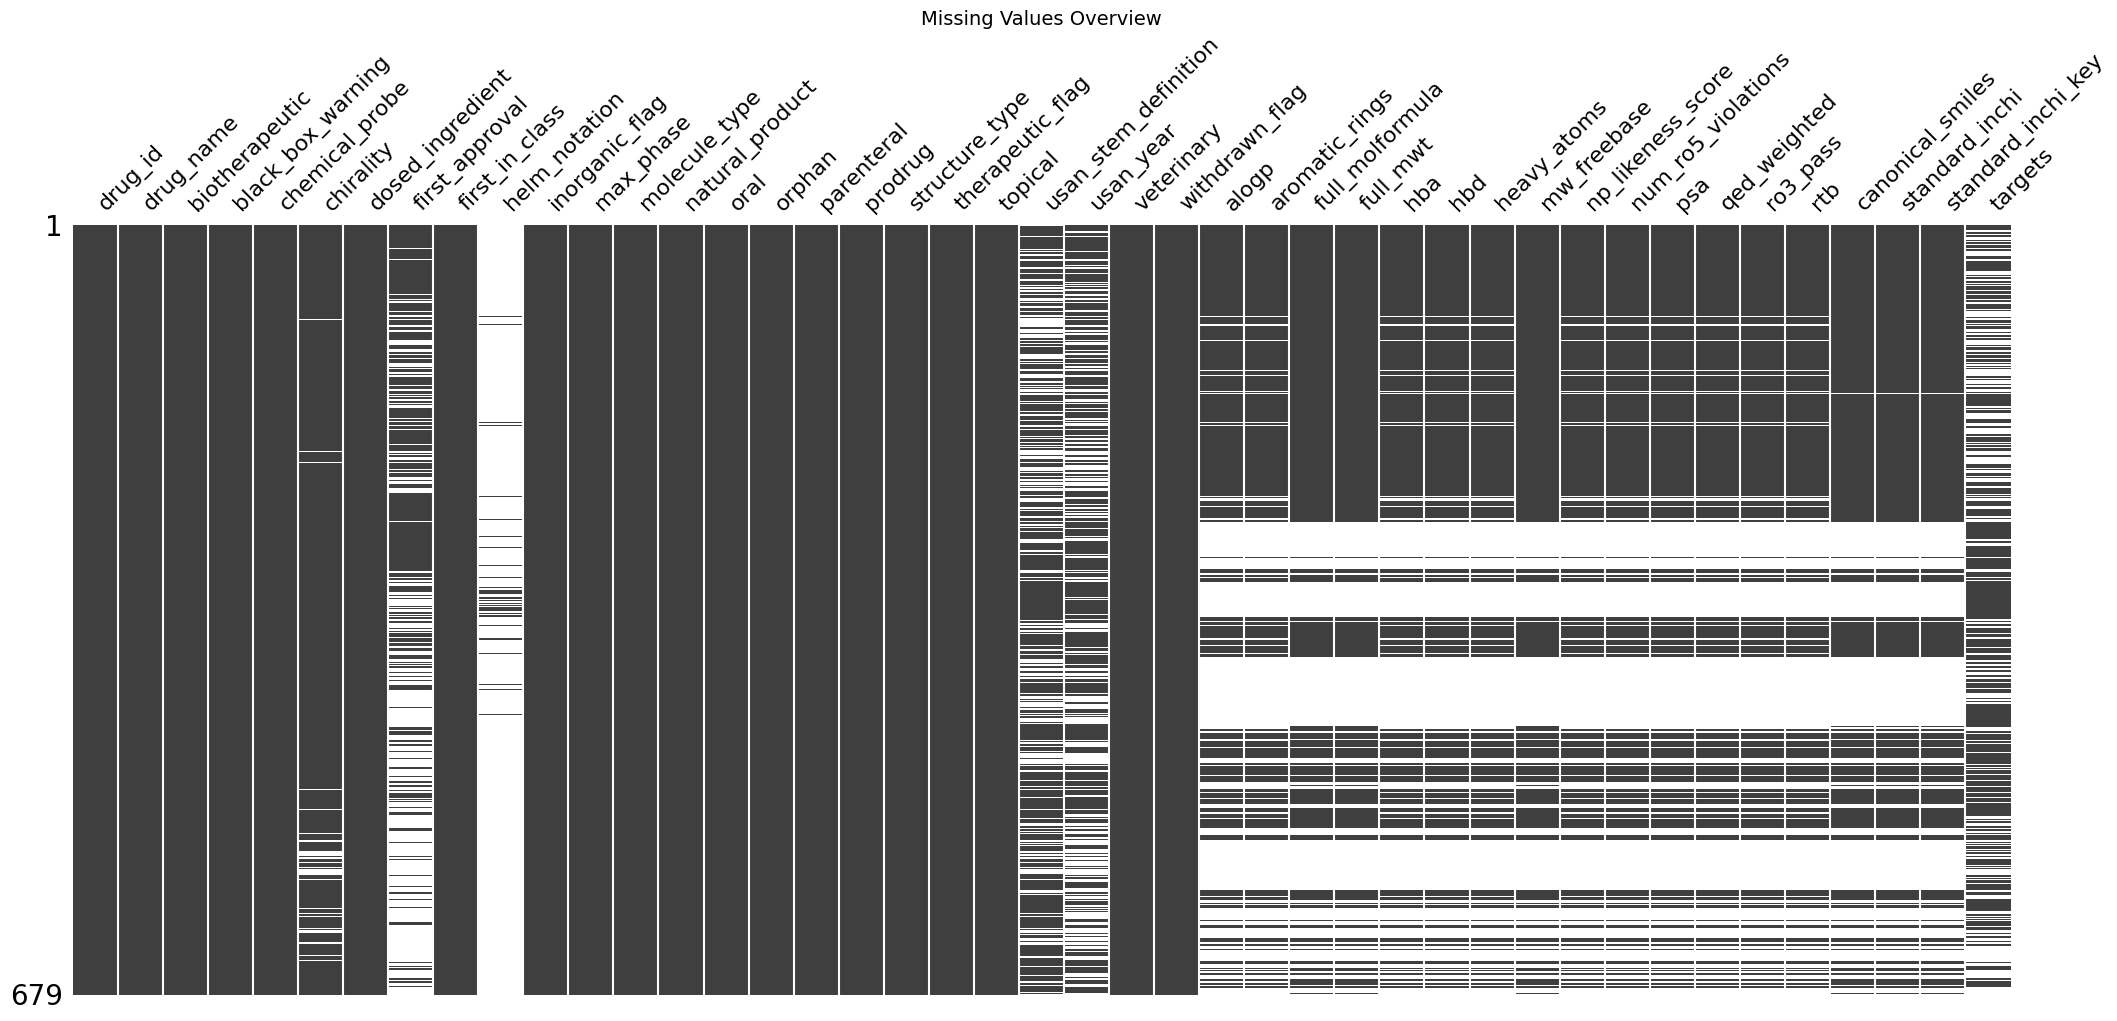

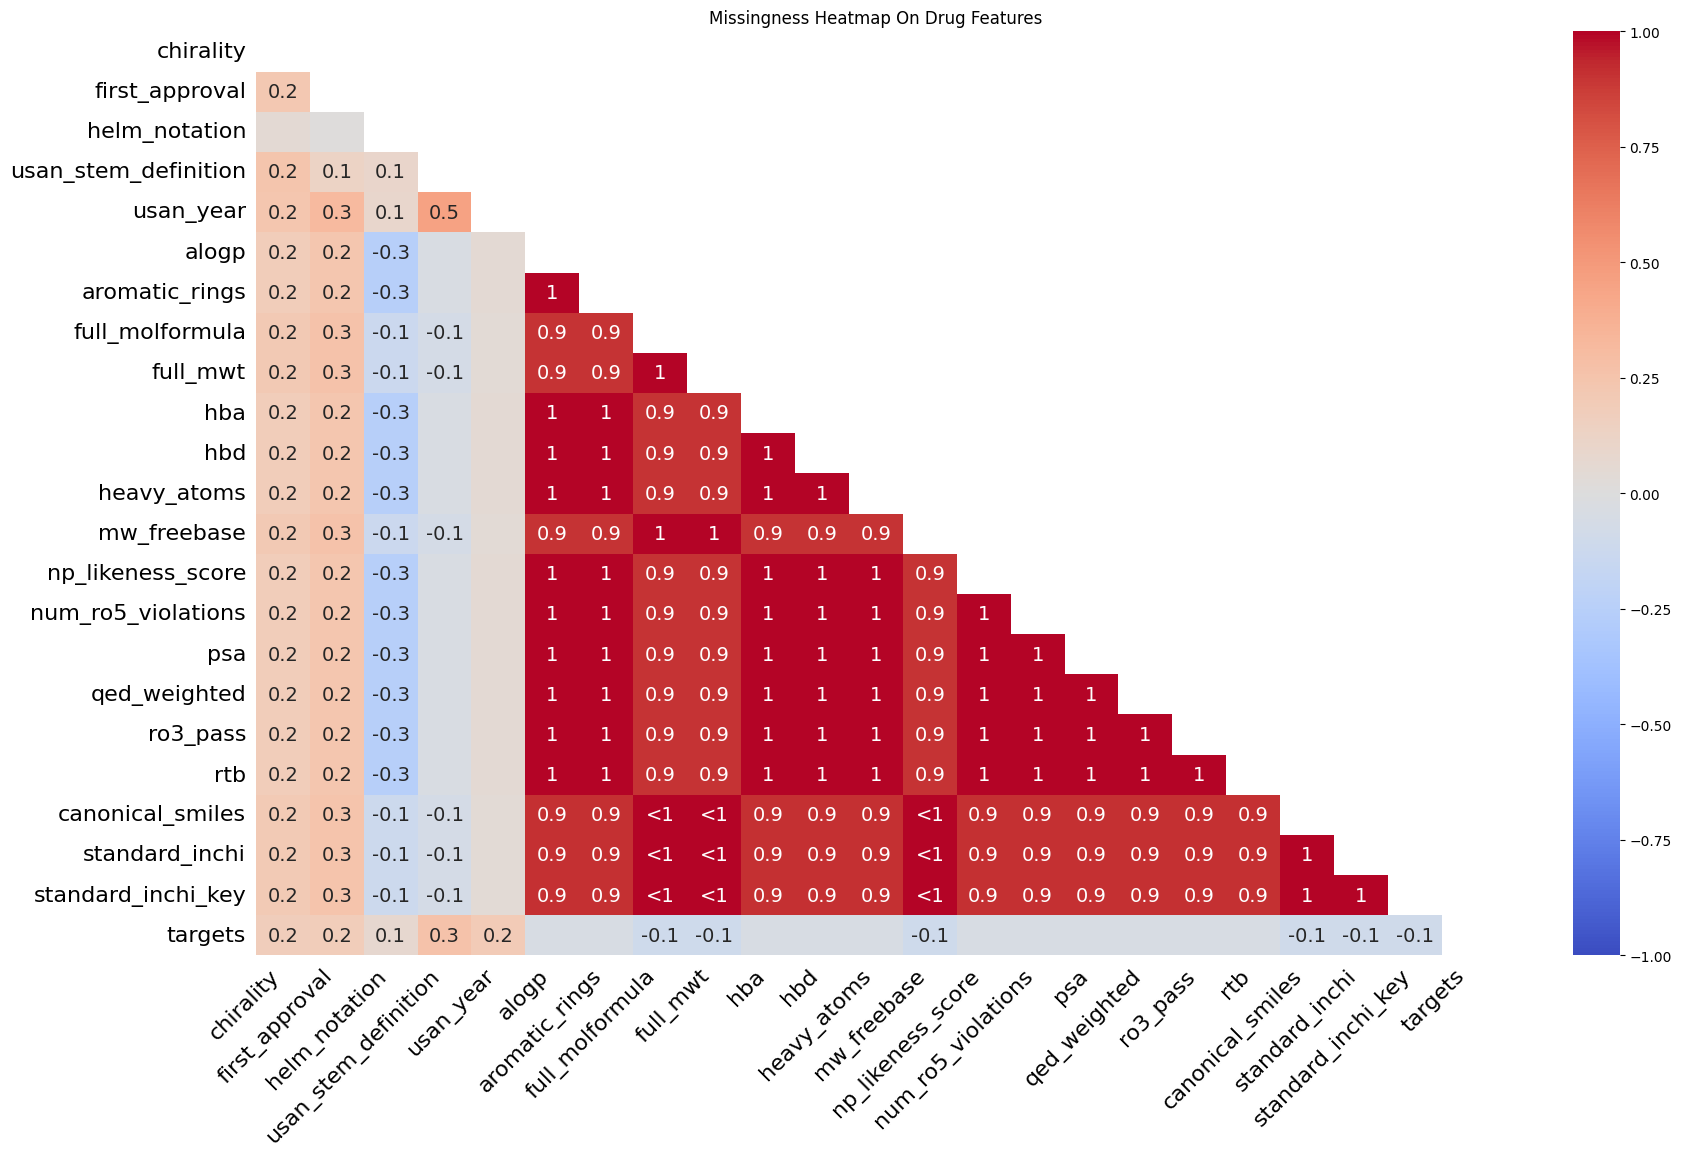

In [ ]:
df = final_drugs_df
# Simple summary
print(df.isna().sum().sort_values(ascending=False))

# Visual overview
plt.figure(figsize=(10, 6))
msno.matrix(df, sparkline=False)
plt.title("Missing Values Overview", fontsize=14)
plt.show()

# Alternatively, a heatmap to see missing patterns
msno.heatmap(df, cmap="coolwarm")
plt.title("Missingness Heatmap On Drug Features")
plt.show()

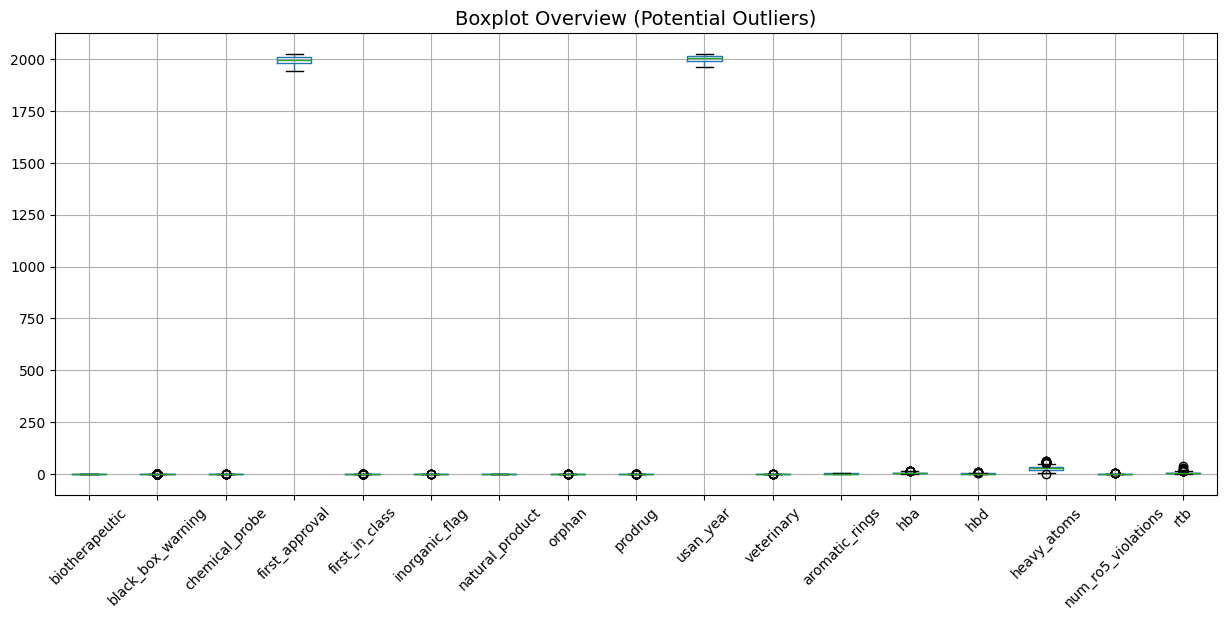

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 6))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplot Overview (Potential Outliers)", fontsize=14)
plt.show()

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color="lightblue")
    plt.title(f"Distribution and Outliers: {col}")
    plt.show()

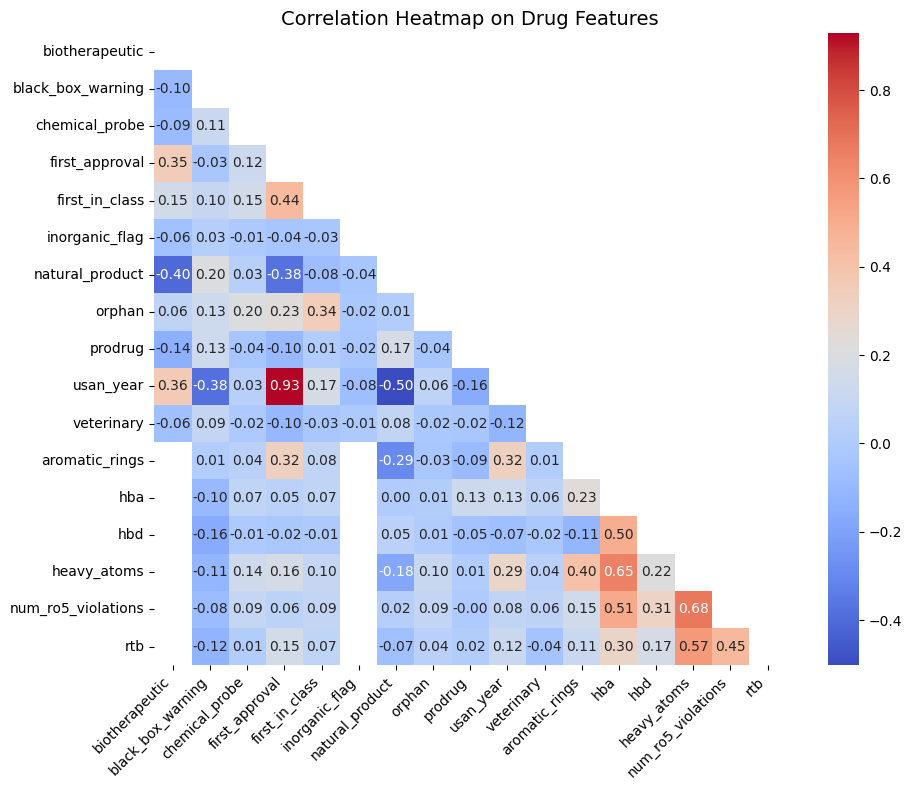

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[numeric_cols].corr()

# Mask lower triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap on Drug Features", fontsize=14)
plt.tight_layout()
plt.show()

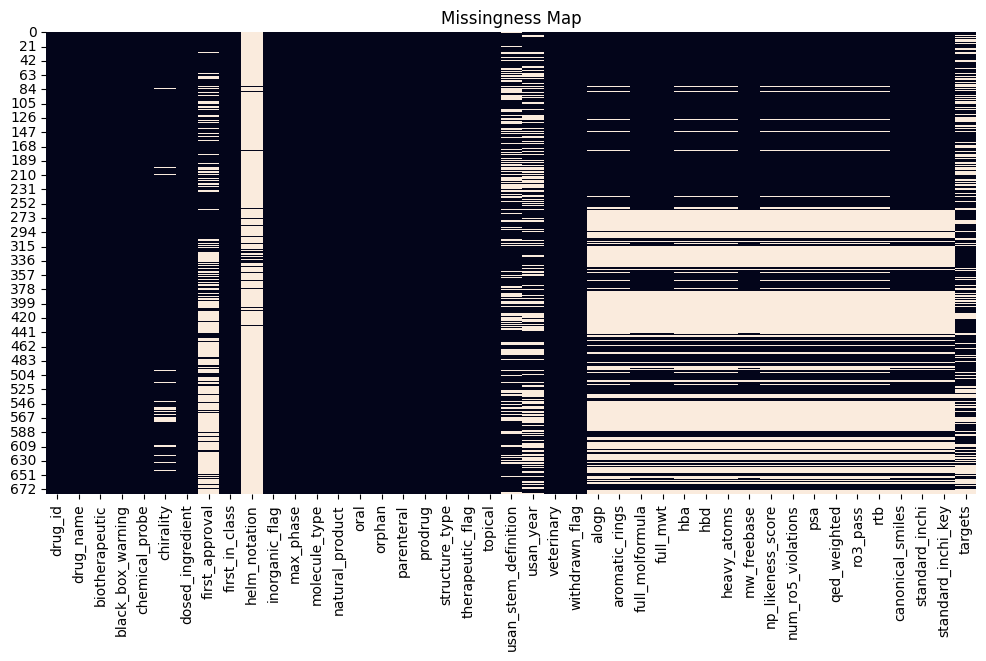

In [ ]:
import numpy as np
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False)  # missing values
plt.title("Missingness Map")
plt.show()

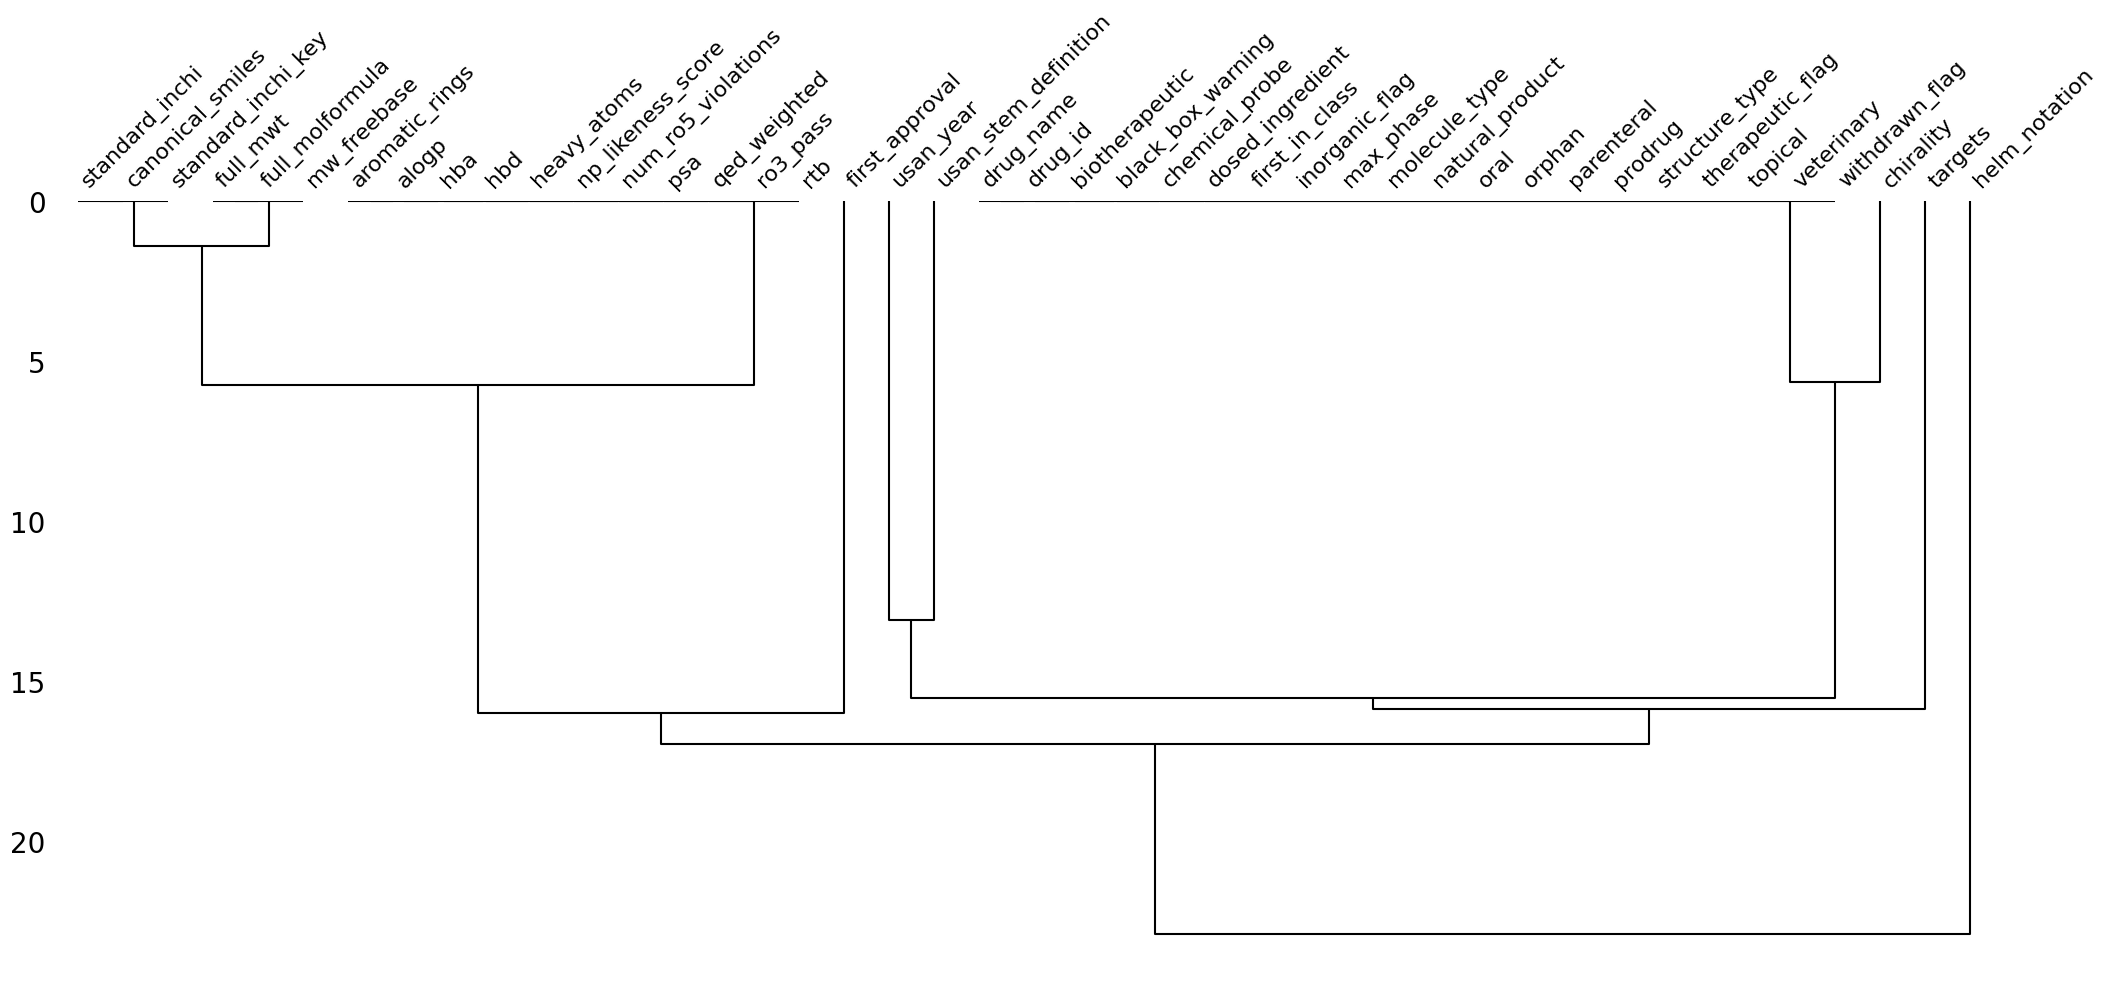

In [ ]:
import missingno as msno
msno.dendrogram(df)
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='VariableA', y='VariableB', hue=df['VariableB'].isna())
plt.title("Scatter of VariableA vs VariableB (color shows missingness)")
plt.show()

KeyError: 'VariableB'

<Figure size 600x400 with 0 Axes>